# Airbnb no Rio de Janeiro: análise exploratória

**Equipe:** (preencher com nome e RA de cada integrante)

**Cidade escolhida:** Rio de Janeiro (RJ, Brasil).

**Base de dados:** tabela detalhada de anúncios (`listings.csv.gz`) do [Inside Airbnb](https://insideairbnb.com/get-the-data/), coleta publicada em 24/06/2026 (anúncios coletados entre 25/06 e 01/07/2026). O arquivo foi descompactado e salvo como `rj_listings.csv`, que não está no repositório por ser grande demais (124,7 MB). Para reproduzir a análise, baixe a base [neste link](https://data.insideairbnb.com/brazil/rj/rio-de-janeiro/2026-06-24/data/listings.csv.gz) e descompacte o arquivo com esse nome na pasta do notebook.

**Perguntas de análise:**
1. Quais amenidades estão mais associadas ao preço das acomodações?
2. Anúncios de Superhosts têm mais demanda do que os de anfitriões comuns? (análise com teste estatístico)
3. Quais bairros do Rio são mais caros, e o ranking se mantém quando consideramos o preço por hóspede?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

df = pd.read_csv('rj_listings.csv') #RJ como cidade escolhida (listings detalhado do Inside Airbnb)

In [2]:
#Tamanho do conjunto de dados
print(f'A base tem {df.shape[0]} anúncios e {df.shape[1]} colunas')

A base tem 48713 anúncios e 90 colunas


In [3]:
print(df.head())


                    id                                       listing_url  \
0  1025196153924029661  https://www.airbnb.com/rooms/1025196153924029661   
1  1697400829368754530  https://www.airbnb.com/rooms/1697400829368754530   
2             42874066             https://www.airbnb.com/rooms/42874066   
3  1543530193994981165  https://www.airbnb.com/rooms/1543530193994981165   
4   831750365913119274   https://www.airbnb.com/rooms/831750365913119274   

        scrape_id last_scraped           source  \
0  20260624212719   2026-06-25      city scrape   
1  20260624212719   2026-06-25      city scrape   
2  20260624212719   2026-06-25      city scrape   
3  20260624212719   2026-06-26  previous scrape   
4  20260624212719   2026-06-25      city scrape   

                                        name  \
0             Quartos disponíveis no Recreio   
1          Casa próxima a Floresta da Tijuca   
2  Alugo uma vaga para sexo feminino Recreio   
3                    Barra Vista maravilhosa

In [4]:
df.columns.to_list()

['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_profile_id',
 'host_profile_url',
 'host_name',
 'host_since',
 'hosts_time_as_user_years',
 'hosts_time_as_user_months',
 'hosts_time_as_host_years',
 'hosts_time_as_host_months',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'price_quote_checkin_date',
 'price_quote_checkout_date',
 'price_quote_total_price',
 'price_quote

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48713 entries, 0 to 48712
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            48713 non-null  int64  
 1   listing_url                                   48713 non-null  str    
 2   scrape_id                                     48713 non-null  int64  
 3   last_scraped                                  48713 non-null  str    
 4   source                                        48713 non-null  str    
 5   name                                          48713 non-null  str    
 6   description                                   47704 non-null  str    
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   48713 non-null  str    
 9   host_id                                       48713 non-null  int64  
 1

In [6]:
#Colunas que possuem nulos
nulos_por_coluna = df.isnull().sum()
print(nulos_por_coluna[nulos_por_coluna > 0])

description                      1009
neighborhood_overview           48713
host_profile_id                     1
host_profile_url                    1
host_name                           1
host_since                      48713
hosts_time_as_user_years            1
hosts_time_as_user_months           1
hosts_time_as_host_years            2
hosts_time_as_host_months           2
host_location                   11120
host_about                      24878
host_response_time              48713
host_response_rate              48713
host_acceptance_rate            48713
host_is_superhost                   1
host_thumbnail_url              48713
host_picture_url                    1
host_neighbourhood              48713
host_listings_count                 1
host_total_listings_count       48713
host_verifications              48713
host_has_profile_pic                1
host_identity_verified              1
neighbourhood                   48713
neighbourhood_group_cleansed    48713
bathrooms   

In [7]:
df['price'].dtype #Checar o tipo da coluna

<StringDtype(storage='python', na_value=nan)>

In [8]:
#remove $ para transformar posteriormente em float
df['price'] = df['price'].str.replace('$', '', regex=False) 
#remove , para transformar posteriormente em float
df['price'] = df['price'].str.replace(',', '', regex=False)

In [9]:
#Transforma em Float
df['price'] = df['price'].astype(float)

In [10]:
df['price'].describe()

count     44542.000000
mean        877.707421
std        4599.612177
min           5.540000
25%         296.710000
50%         452.670000
75%         761.537500
max      574013.000000
Name: price, dtype: float64

In [11]:
df['amenities'].describe()

count                                             48713
unique                                            44757
top       ["Wifi", "Kitchen", "TV", "Air conditioning"]
freq                                                130
Name: amenities, dtype: object

In [12]:
#Descobre as top 5 amenidades para criar categorias binarias
pd.Series([item for sublist in df['amenities'].dropna().apply(ast.literal_eval) for item in sublist]).value_counts().head(5)

Wifi                44551
Kitchen             43868
TV                  32118
Hot water           31919
Air conditioning    31605
Name: count, dtype: int64

As cinco amenidades escolhidas foram Wifi, Kitchen, TV, Hot water e Air conditioning, pois apresentaram as maiores frequências na base. Dessa forma, a análise concentra-se nas comodidades mais comuns entre os anúncios da cidade.

In [13]:
top_amenidades = [
    'Wifi',
    'Kitchen',
    'TV',
    'Hot water',
    'Air conditioning'
] #Cria uma coluna para cada uma das 5 maiores amenidades

for amenidade in top_amenidades:
    df[amenidade] = df['amenities'].apply(
        lambda x: 1 if amenidade in x else 0
    )

In [14]:
df[top_amenidades].head()

,Wifi,Kitchen,TV,Hot water,Air conditioning
0,1,1,0,0,1
1,0,1,1,0,0
2,0,1,1,1,1
3,1,1,1,0,1
4,1,0,0,0,0


Pergunta 1 a ser respondida: Quais amenidades estão mais associadas ao preço das acomodações?

In [15]:
#para cada uma das 5 amenidades, o preço mediano dos anúncios que possuem a 
#amenidade com o preço mediano dos anúncios que não possuem.
for amenidade in top_amenidades:
    results = df.groupby(amenidade)['price'].agg(
        ['count', 'mean', 'median']
    )

    print(f'\n {amenidade} ')
    print(results)


 Wifi 
      count         mean  median
Wifi                            
0      3429  1132.038804   457.0
1     41113   856.495096   451.0

 Kitchen 
         count        mean  median
Kitchen                           
0         4081  831.512078   343.0
1        40461  882.366802   457.0

 TV 
    count        mean  median
TV                           
0    4625  1082.26760   310.0
1   39917   854.00597   462.5

 Hot water 
           count         mean  median
Hot water                            
0          14920  1128.072866   479.5
1          29622   751.603430   440.0

 Air conditioning 
                  count        mean  median
Air conditioning                           
0                 15688  725.907768   397.5
1                 28854  960.241315   485.0


Quanto a mediana do preco muda comparando acomodacoes que tem determinada amenidade com as que nao tem.

In [16]:
#Quanto o preço mediano varia, em termos percentuais, entre acomodações que 
#possuem determinada amenidade e acomodações que não possuem?
percentuais = {}

for amenidade in top_amenidades:
    results = df.groupby(amenidade)['price'].agg(
        ['count', 'mean', 'median']
    )

    mediana_sem = results.loc[0, 'median']
    mediana_com = results.loc[1, 'median']

    percentuais[amenidade] = (
        (mediana_com - mediana_sem) / mediana_sem
    ) * 100

percentuais = pd.Series(percentuais).sort_values(ascending=False)

percentuais

TV                  49.193548
Kitchen             33.236152
Air conditioning    22.012579
Wifi                -1.312910
Hot water           -8.237748
dtype: float64

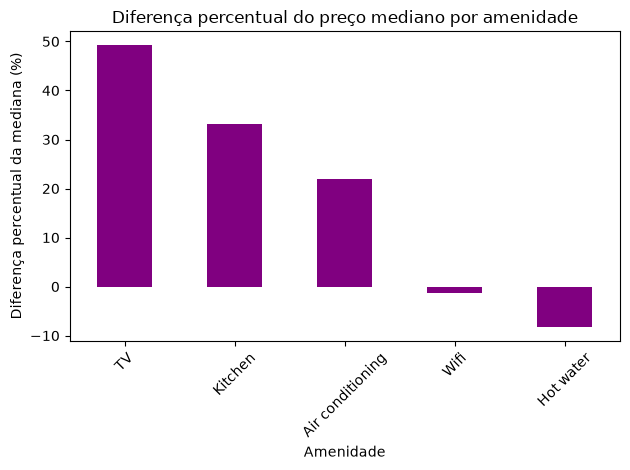

In [17]:
percentuais.plot(kind='bar', color='purple')

plt.xlabel('Amenidade')
plt.ylabel('Diferença percentual da mediana (%)')
plt.title('Diferença percentual do preço mediano por amenidade')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Análise aprofundada: A associação entre as amenidades e o preço das acomodações permanece quando controlamos por características da acomodação?

In [18]:
#Comparação entre acomodações com e sem TV
df['has_tv'] = df['amenities'].str.lower().str.contains('tv', na=False)
df['has_tv'] = df['has_tv'].map({True: 'Com TV', False: 'Sem TV'})
tabela_preco= pd.pivot_table(
    df,
    values='price', 
    index=['bedrooms'],
    columns=['has_tv'], 
    aggfunc='median' 
).round(2)
tabela_preco.index = tabela_preco.index.astype(int)
tabela_preco['Diferença (R$)'] = tabela_preco['Com TV'] - tabela_preco['Sem TV']
tabela_preco = tabela_preco.fillna('-')

tabela_volume = pd.pivot_table(
    df,
    values='price', 
    index=['bedrooms'],
    columns=['has_tv'],
    aggfunc='count' 
).fillna(0)
tabela_volume.index = tabela_volume.index.astype(int)
display(tabela_preco.head(7)) 
display(tabela_volume.head(7))

has_tv,Com TV,Sem TV,Diferença (R$)
bedrooms,,,
0,171.0,177.0,-6.0
1,388.0,288.75,99.25
2,649.33,609.34,39.99
3,1001.5,930.5,71.0
4,1872.92,1851.34,21.58
5,4767.0,3423.67,1343.33
6,5502.35,1142.0,4360.35


has_tv,Com TV,Sem TV
bedrooms,,
0,6.0,1.0
1,20940.0,2060.0
2,9405.0,600.0
3,3491.0,177.0
4,732.0,64.0
5,313.0,27.0
6,128.0,14.0


Pode se notar que, excluindo os estudios(bedrooms=0), há uma disparidade de preço meio inconsistente comparando exemplos com e sem tv.   
Vale resaltar que a quantidade de locais sem tv é muito abaixo da de locais com tv.   


Locais com apenas um quarto são os que possuem mais dados, onde a mediana retorna que há uma diferença de R$99 reais entre quartos com e sem TV.   
De dois a quatro quartos, a presença da TV afeta menos o preço, considerando que quartos a mais já adicionam um bom peso ao preço.   

Os ambientes com 5+ quartos são questionaveis a analise, pode se extrair que a falta de uma TV indica que outras qualidades também não estão presentes, levando a grande diferença de preço, porem devido a quantidade de dados, não pode se extrair muito mais do que isto.

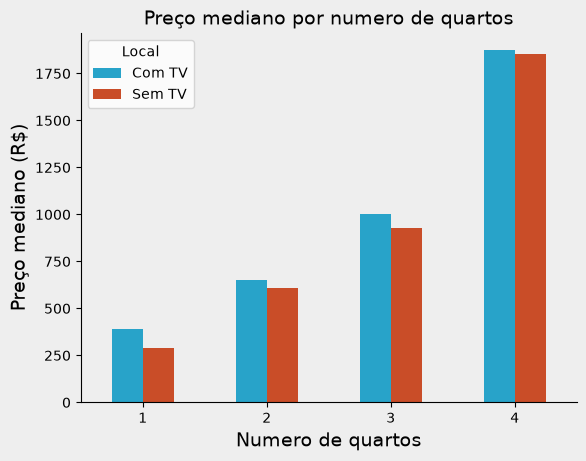

In [19]:
tabela_grafico = pd.pivot_table(
    df[(df['bedrooms'] >= 1) & (df['bedrooms'] <= 4)],
    values='price', 
    index=['bedrooms'],
    columns=['has_tv'], 
    aggfunc='median' 
)
tabela_grafico.index = tabela_grafico.index.astype(int)
ax = tabela_grafico.plot(kind='bar', width=0.5,color=["#28a3c9","#c94d28"])
ax.set_facecolor('#eeeeee') 
ax.figure.patch.set_facecolor('#eeeeee')
sns.despine(top=True, right=True)
plt.title('Preço mediano por numero de quartos', fontsize=14)
plt.xlabel('Numero de quartos', fontsize=14)
plt.ylabel('Preço mediano (R$)', fontsize=14)
plt.legend(title='Local')
plt.xticks(rotation=0)
plt.show()

Conseguimos evidenciar melhor a discrepancia de preço e dar luz ao que foi abordado na tabela anterior, elminando estudios e locais com mais de 4 quartos, é possivel ver uma crescente estável que mantém os padrões de locais sem tv serem mais baratos.

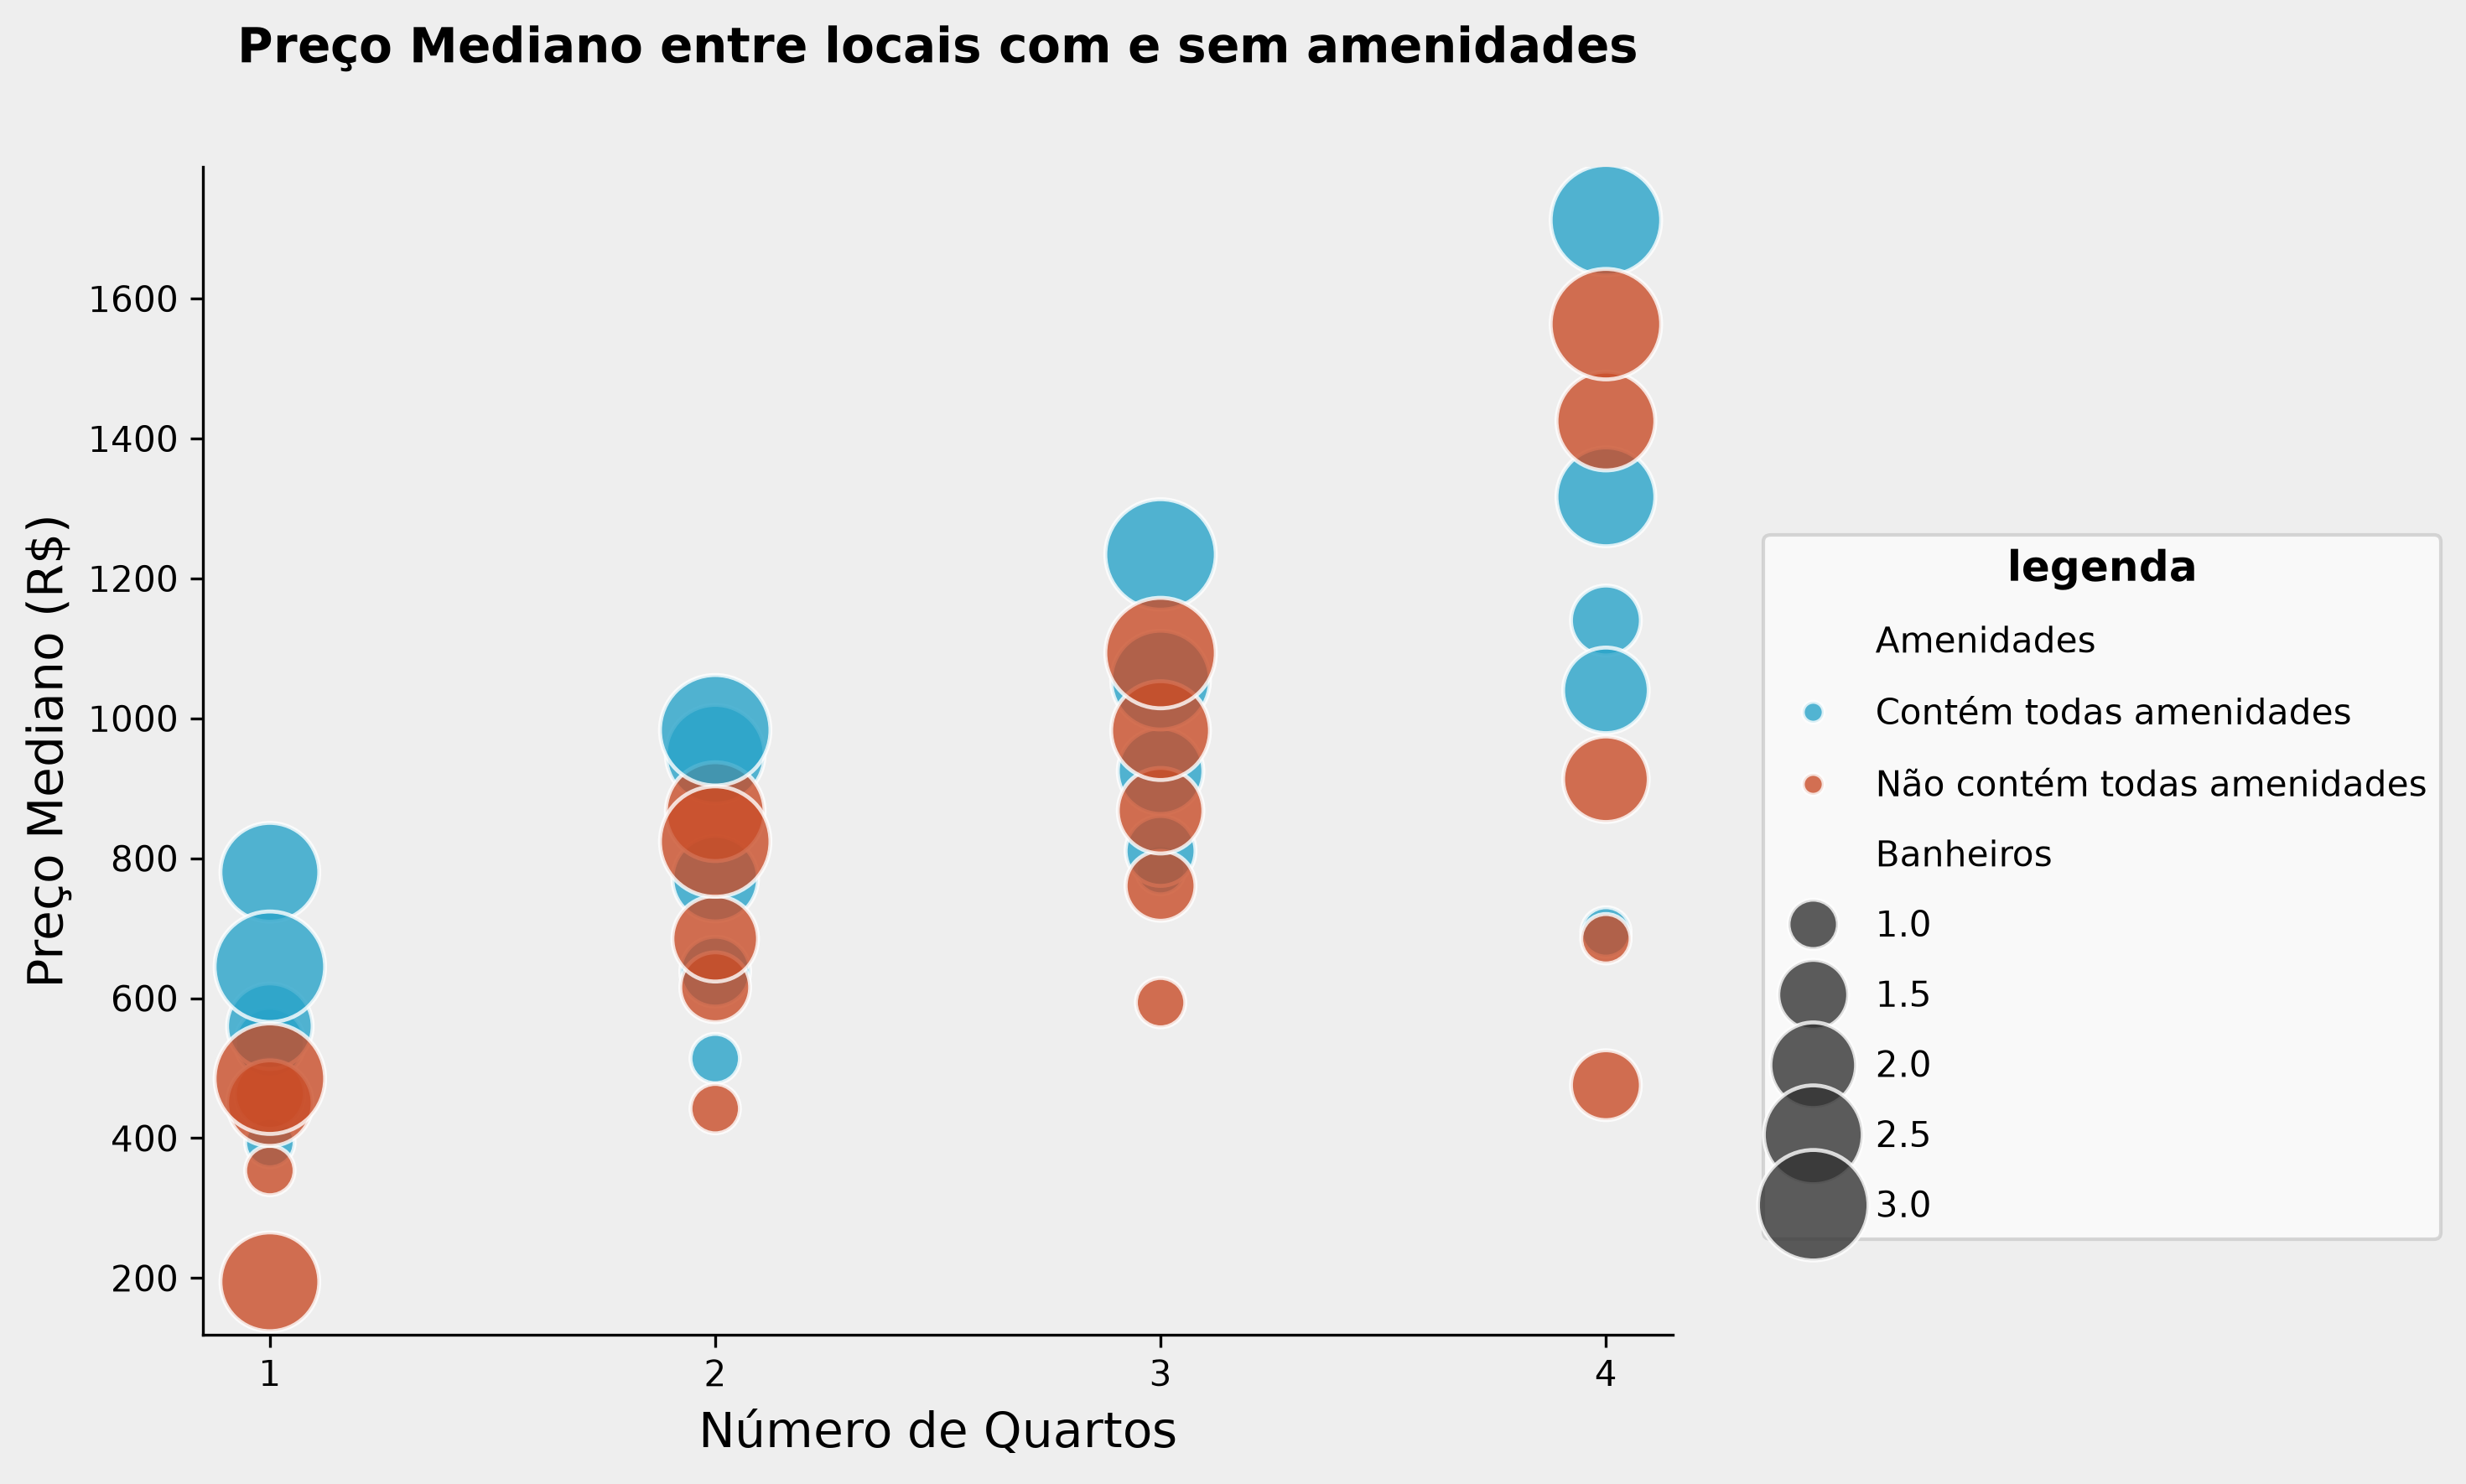

In [20]:
lista_amenidades = ['tv', 'kitchen', 'air conditioning']
nome_pacote = 'todas amenidades'

df_temp = df.copy()
condicao_combo = pd.Series(True, index=df_temp.index)

for amenidade in lista_amenidades:
    tem = df_temp['amenities'].str.lower().str.contains(amenidade.lower(), na=False)
    condicao_combo = condicao_combo & tem

nome_coluna = 'Amenidades'
df_temp[nome_coluna] = condicao_combo.map({
    True: f'Contém {nome_pacote}', 
    False: f'Não contém {nome_pacote}'
})

df_grafico = df_temp[
    (df_temp['bedrooms'] >= 1) &     
    (df_temp['bathrooms'] >= 1) &              
    (df_temp['room_type'] != 'Hotel room') &   
    (df_temp['room_type'] != 'Shared room') &    
    (df_temp['bedrooms'] <= 4) & 
    (df_temp['bathrooms'] <= 3)
]
df_agrupado = df_grafico.groupby(['bedrooms', 'bathrooms', nome_coluna])['price'].median().reset_index()
df_agrupado = df_agrupado.rename(columns={'bathrooms': 'Banheiros'})

plt.figure(figsize=(10, 6), dpi=300)
plt.gca().set_facecolor('#eeeeee')
plt.gcf().patch.set_facecolor('#eeeeee')

ax = sns.scatterplot(
    data=df_agrupado,
    x='bedrooms',
    y='price',
    size='Banheiros',
    sizes=(200, 1000),
    hue=nome_coluna,
    palette=["#28a3c9","#c94d28"], 
    alpha=0.8,
)
sns.despine(top=True, right=True)

plt.title('Preço Mediano entre locais com e sem amenidades', fontsize=14, fontweight='bold', loc='center', pad=30)
plt.xlabel("Número de Quartos", fontsize=14)
plt.ylabel("Preço Mediano (R$)", fontsize=14)
plt.tick_params(axis='both', labelsize=10) 
plt.xticks([1, 2, 3, 4])
plt.legend(
    bbox_to_anchor=(1.05, 0.7), 
    loc='upper left', frameon=True, 
    facecolor='#fdfdfd', 
    labelspacing=1.0, 
    title="legenda",
    prop={'size': 10},
    title_fontproperties={'weight': 'bold', 'size': 12}
)
plt.tight_layout()
plt.show()

Embora o gráfico de barras sejá muito bom para visualização, o scatterplot apresenta mais dimensões para comparação, aumentando os fatores para a análise. 
Pode-se observar a disparidade criada ao trazer o número de banheiros a comparação. É possível identificar que ambientes com 1 quarto seguem a hiptese

Porém, pode se observar que ao progredir pelo número de quartos, a diferença entre os preços cai. Ainda sim, o grafico mosra que os locais com as 3 maiores amenidades presentes ainda lideram nos preços. Vale notar que ambientes com 4 quartos começam a deturpar o padrão. Isso se deve ao impacto que cada local tem na mediana e à quantidade menor de dados com quartos e banheiros elevados.

Após estes fatores, pode se concluir que a associação entre as amenidades e o preço das acomodações permanece ao analizar diferentes locais. Com um baixo número de quartos e banheiros, pode-se ver que o preço aumenta mais consistente quando tem amenidades. Porém, ao escalar o número de banheiros e quartos, há uma queda nesta consistencia.

## Pergunta 2: Anúncios de Superhosts têm mais demanda do que os de anfitriões comuns?

Como a base não registra reservas diretamente, usamos `reviews_per_month` (média de avaliações recebidas por mês) como **proxy de demanda**: quanto mais hóspedes passam pelo anúncio, mais avaliações ele tende a acumular. Usamos a taxa mensal em vez do total de avaliações (`number_of_reviews`) para não favorecer anúncios simplesmente por estarem há mais tempo na plataforma.

**Filtros aplicados:**
- apenas anúncios com pelo menos 1 avaliação (sem avaliações, `reviews_per_month` é nulo);
- apenas anúncios com `host_is_superhost` informado;
- apenas *Entire home/apt* e *Private room*, que concentram quase todos os anúncios; quartos de hotel e compartilhados têm dinâmicas diferentes e poucos dados.

In [21]:
#Filtros: apenas anúncios com pelo menos 1 avaliação e com o status de Superhost informado
df_q2 = df[
    (df['number_of_reviews'] > 0) &
    (df['reviews_per_month'].notna()) &
    (df['host_is_superhost'].notna())
].copy()

df_q2['Anfitrião'] = df_q2['host_is_superhost'].map({'t': 'Superhost', 'f': 'Anfitrião comum'})

#Mantém os dois tipos de acomodação mais comuns, para comparar anúncios parecidos
tipos = ['Casa/apto inteiro', 'Quarto privativo']
df_q2['Tipo'] = df_q2['room_type'].map({
    'Entire home/apt': 'Casa/apto inteiro',
    'Private room': 'Quarto privativo'
})
df_q2 = df_q2[df_q2['Tipo'].isin(tipos)]

print(f'Anúncios na base: {len(df)} | Anúncios após filtros: {len(df_q2)}')
df_q2['Anfitrião'].value_counts()

Anúncios na base: 48713 | Anúncios após filtros: 38443


Anfitrião
Anfitrião comum    22153
Superhost          16290
Name: count, dtype: int64

In [22]:
#Resumo geral por tipo de anfitrião
tabela_q2 = df_q2.groupby('Anfitrião').agg(
    anuncios=('id', 'count'),
    media_reviews_mes=('reviews_per_month', 'mean'),
    mediana_reviews_mes=('reviews_per_month', 'median'),
    mediana_preco=('price', 'median'),
    nota_media=('review_scores_rating', 'mean')
).round(2)
display(tabela_q2)

#Mediana de reviews por mês separando por tipo de acomodação (tabela que origina o gráfico)
tabela_q2_tipo = pd.pivot_table(
    df_q2,
    values='reviews_per_month',
    index='Tipo',
    columns='Anfitrião',
    aggfunc=['count', 'median']
).round(2)
display(tabela_q2_tipo)

,anuncios,media_reviews_mes,mediana_reviews_mes,mediana_preco,nota_media
Anfitrião,,,,,
Anfitrião comum,22153,0.91,0.47,446.0,4.75
Superhost,16290,1.88,1.59,411.0,4.88


count                    median          
Anfitrião         Anfitrião comum Superhost Anfitrião comum Superhost
Tipo                                                                 
Casa/apto inteiro           17790     14561            0.55      1.67
Quarto privativo             4363      1729            0.24      0.86

O gráfico abaixo é um boxplot de `reviews_per_month`: a linha central de cada caixa é a **mediana**, e a caixa vai do 1º ao 3º quartil. Os outliers foram omitidos da visualização (mas não dos dados nem do teste) para que as caixas fiquem legíveis.

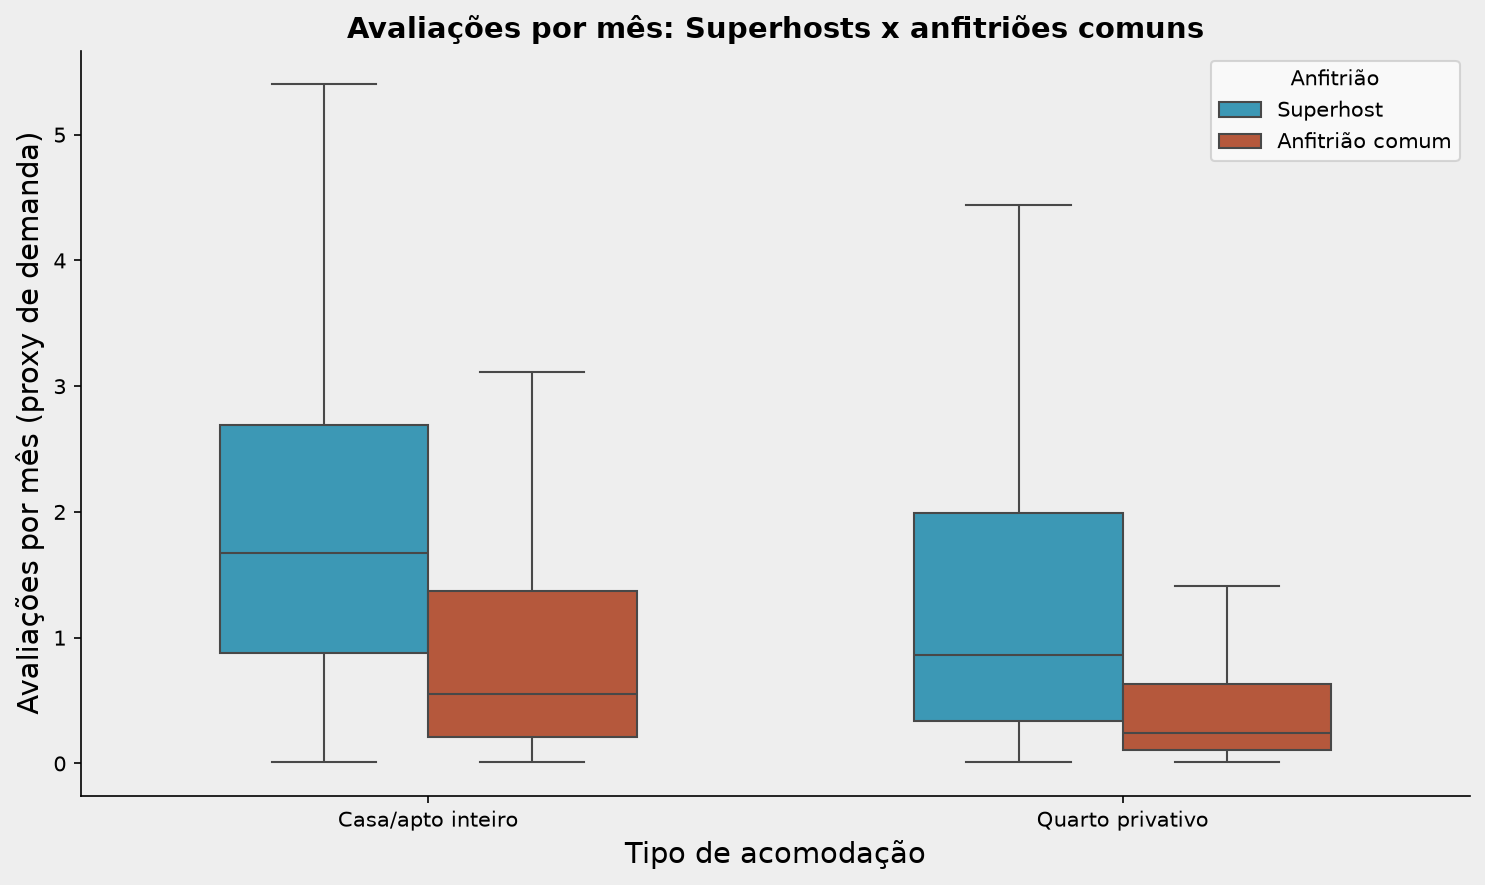

In [23]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
ax.set_facecolor('#eeeeee')
fig.patch.set_facecolor('#eeeeee')

sns.boxplot(
    data=df_q2,
    x='Tipo',
    y='reviews_per_month',
    hue='Anfitrião',
    order=tipos,
    hue_order=['Superhost', 'Anfitrião comum'],
    palette=["#28a3c9", "#c94d28"],
    showfliers=False, #outliers omitidos para facilitar a leitura
    width=0.6,
    ax=ax
)
sns.despine(top=True, right=True)

plt.title('Avaliações por mês: Superhosts x anfitriões comuns', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de acomodação', fontsize=14)
plt.ylabel('Avaliações por mês (proxy de demanda)', fontsize=14)
plt.legend(title='Anfitrião', frameon=True, facecolor='#fdfdfd')
plt.tight_layout()
plt.show()

### Teste estatístico

**Pergunta:** a demanda (reviews por mês) dos anúncios de Superhosts é maior que a dos anfitriões comuns?

- **H₀:** a distribuição de `reviews_per_month` é igual entre Superhosts e anfitriões comuns.
- **H₁:** os anúncios de Superhosts tendem a ter `reviews_per_month` maior (teste unilateral).
- **Nível de significância:** α = 0,05

**Escolha do teste:** usamos o **Mann-Whitney U**, pois comparamos dois grupos independentes e a variável `reviews_per_month` é fortemente assimétrica (muitos anúncios com poucas avaliações e poucos com muitas), não seguindo distribuição normal. Por ser não paramétrico, o teste compara os postos (ranks) dos valores, sem exigir normalidade e sendo pouco sensível a outliers. O teste t, ao contrário, compara médias e assume normalidade.

In [24]:
from scipy.stats import mannwhitneyu

#Teste unilateral: Superhosts têm reviews_per_month maior?
def teste_superhost(dados, rotulo):
    superhost = dados.loc[dados['Anfitrião'] == 'Superhost', 'reviews_per_month']
    comum = dados.loc[dados['Anfitrião'] == 'Anfitrião comum', 'reviews_per_month']

    stat, p = mannwhitneyu(superhost, comum, alternative='greater')
    #Correlação rank-biserial como tamanho de efeito
    efeito = 2 * stat / (len(superhost) * len(comum)) - 1

    print(f'{rotulo}: U = {stat:.0f} | p-valor = {p:.4g} | efeito (rank-biserial) = {efeito:.3f}')

teste_superhost(df_q2, 'Todos os anúncios')
for tipo in tipos:
    teste_superhost(df_q2[df_q2['Tipo'] == tipo], tipo)

Todos os anúncios: U = 269044482 | p-valor = 0 | efeito (rank-biserial) = 0.491
Casa/apto inteiro: U = 191291160 | p-valor = 0 | efeito (rank-biserial) = 0.477
Quarto privativo: U = 5521654 | p-valor = 3.328e-176 | efeito (rank-biserial) = 0.464


**Interpretação do teste:** (preencher após rodar) se o p-valor for menor que 0,05, rejeitamos H₀ e concluímos que anúncios de Superhosts recebem mais avaliações por mês, ou seja, apresentam mais demanda. O tamanho de efeito (correlação rank-biserial, de -1 a 1) indica se essa diferença é pequena (~0,1), média (~0,3) ou grande (~0,5). Com muitos anúncios, até diferenças pequenas ficam significativas, por isso é importante olhar o efeito e não só o p-valor.

**Limitações da proxy:** nem todo hóspede deixa avaliação, então `reviews_per_month` subestima as reservas reais. Anúncios muito novos podem ter valores distorcidos, e a relação pode ter causalidade reversa: o selo de Superhost exige um mínimo de estadias e boas notas, então ter muita demanda ajuda a virar Superhost, e não só o contrário.

Pergunta 3 a ser respondida: Quais bairros do Rio são mais caros, e o ranking se mantém quando consideramos o preço por hóspede?

Um bairro pode parecer caro apenas porque seus imóveis são maiores. Para separar o efeito da localização do efeito do tamanho das acomodações, criamos a variável derivada `preco_por_hospede = price / accommodates`, ou seja, o preço da diária dividido pelo máximo de hóspedes daquela acomodação.

Filtros aplicados:

Apenas Entire home/apt, para comparar acomodações do mesmo tipo: quartos privativos e compartilhados são naturalmente mais baratos, e a proporção deles varia entre os bairros;

Apenas anúncios com preço informado;

Apenas bairros com pelo menos 100 anúncios, pois medianas calculadas com poucos anúncios podem ser instáveis.

Para agregação usamos a mediana, e não a média, pois o preço é muito assimétrico: há anúncios de até 574 mil reais por noite, que distorcem a média.

In [25]:
df_q3 = df[
    (df['room_type'] == 'Entire home/apt') &
    (df['price'].notna())
].copy()

df_q3['preco_por_hospede'] = df_q3['price'] / df_q3['accommodates']

print(f'Anúncios na base: {len(df)} | Casas/aptos inteiros com preço: {len(df_q3)}')
print(f'Bairros com pelo menos 1 anúncio: {df_q3["neighbourhood_cleansed"].nunique()}')

Anúncios na base: 48713 | Casas/aptos inteiros com preço: 36141
Bairros com pelo menos 1 anúncio: 151


In [26]:
tabela_q3 = df_q3.groupby('neighbourhood_cleansed').agg(
    anuncios=('id', 'count'),
    preco_mediano=('price', 'median'),
    preco_hospede_mediano=('preco_por_hospede', 'median'),
    hospedes_mediano=('accommodates', 'median')
)

tabela_q3 = tabela_q3[tabela_q3['anuncios']>= 100]

tabela_q3['posicao_preco'] = tabela_q3['preco_mediano'].rank(ascending=False, method='min').astype(int)
tabela_q3['posicao_por_hospede'] = tabela_q3['preco_hospede_mediano'].rank(ascending=False, method='min').astype(int)
tabela_q3['mudanca_posicao'] = tabela_q3['posicao_preco'] - tabela_q3['posicao_por_hospede']

tabela_q3 = tabela_q3.sort_values('preco_mediano', ascending=False).round(2)
tabela_q3.index.name = 'Bairro'

cobertura = tabela_q3['anuncios'].sum() / len(df_q3) * 100
print(f'Bairros com 100+ anúncios: {len(tabela_q3)} | cobrem {cobertura:.1f}% dos anúncios filtrados')
display(tabela_q3)

Bairros com 100+ anúncios: 32 | cobrem 94.9% dos anúncios filtrados


,anuncios,preco_mediano,preco_hospede_mediano,hospedes_mediano,posicao_preco,posicao_por_hospede,mudanca_posicao
Bairro,,,,,,,
Joá,144,7703.25,724.57,10.0,1,1,0
São Conrado,183,1883.00,366.17,6.0,2,2,0
Itanhangá,106,1769.00,212.72,8.0,3,6,-3
Lagoa,215,912.00,232.50,4.0,4,4,0
Leblon,1670,817.92,232.52,4.0,5,3,2
Ipanema,3210,750.89,204.36,4.0,6,8,-2
Gávea,164,745.84,204.77,4.0,7,7,0
Jardim Botânico,137,745.67,218.07,4.0,8,5,3
Barra da Tijuca,2957,674.50,175.50,4.0,9,9,0


Cada linha da tabela é um bairro, com a quantidade de anúncios, o preço mediano, o preço mediano por hóspede, a mediana de hóspedes por anúncio, a posição no ranking considerando apenas o preço, a posição no ranking considerando o valor por hóspede e quantas posições o bairro sobe (positivo) ou cai (negativo) de um ranking para o outro.

In [27]:
correlacao = tabela_q3['preco_mediano'].corr(tabela_q3['preco_hospede_mediano'], method='spearman')
print(f'Correlação de Spearman entre os dois rankings: {correlacao:.2f}')


Correlação de Spearman entre os dois rankings: 0.85


Para resumir em um número o quanto os dois rankings concordam, calculamos a correlação de Spearman entre eles: ela compara a ordem dos bairros, e vai de -1 a 1 (1 = exatamente a mesma ordem; 0 = nenhuma relação).

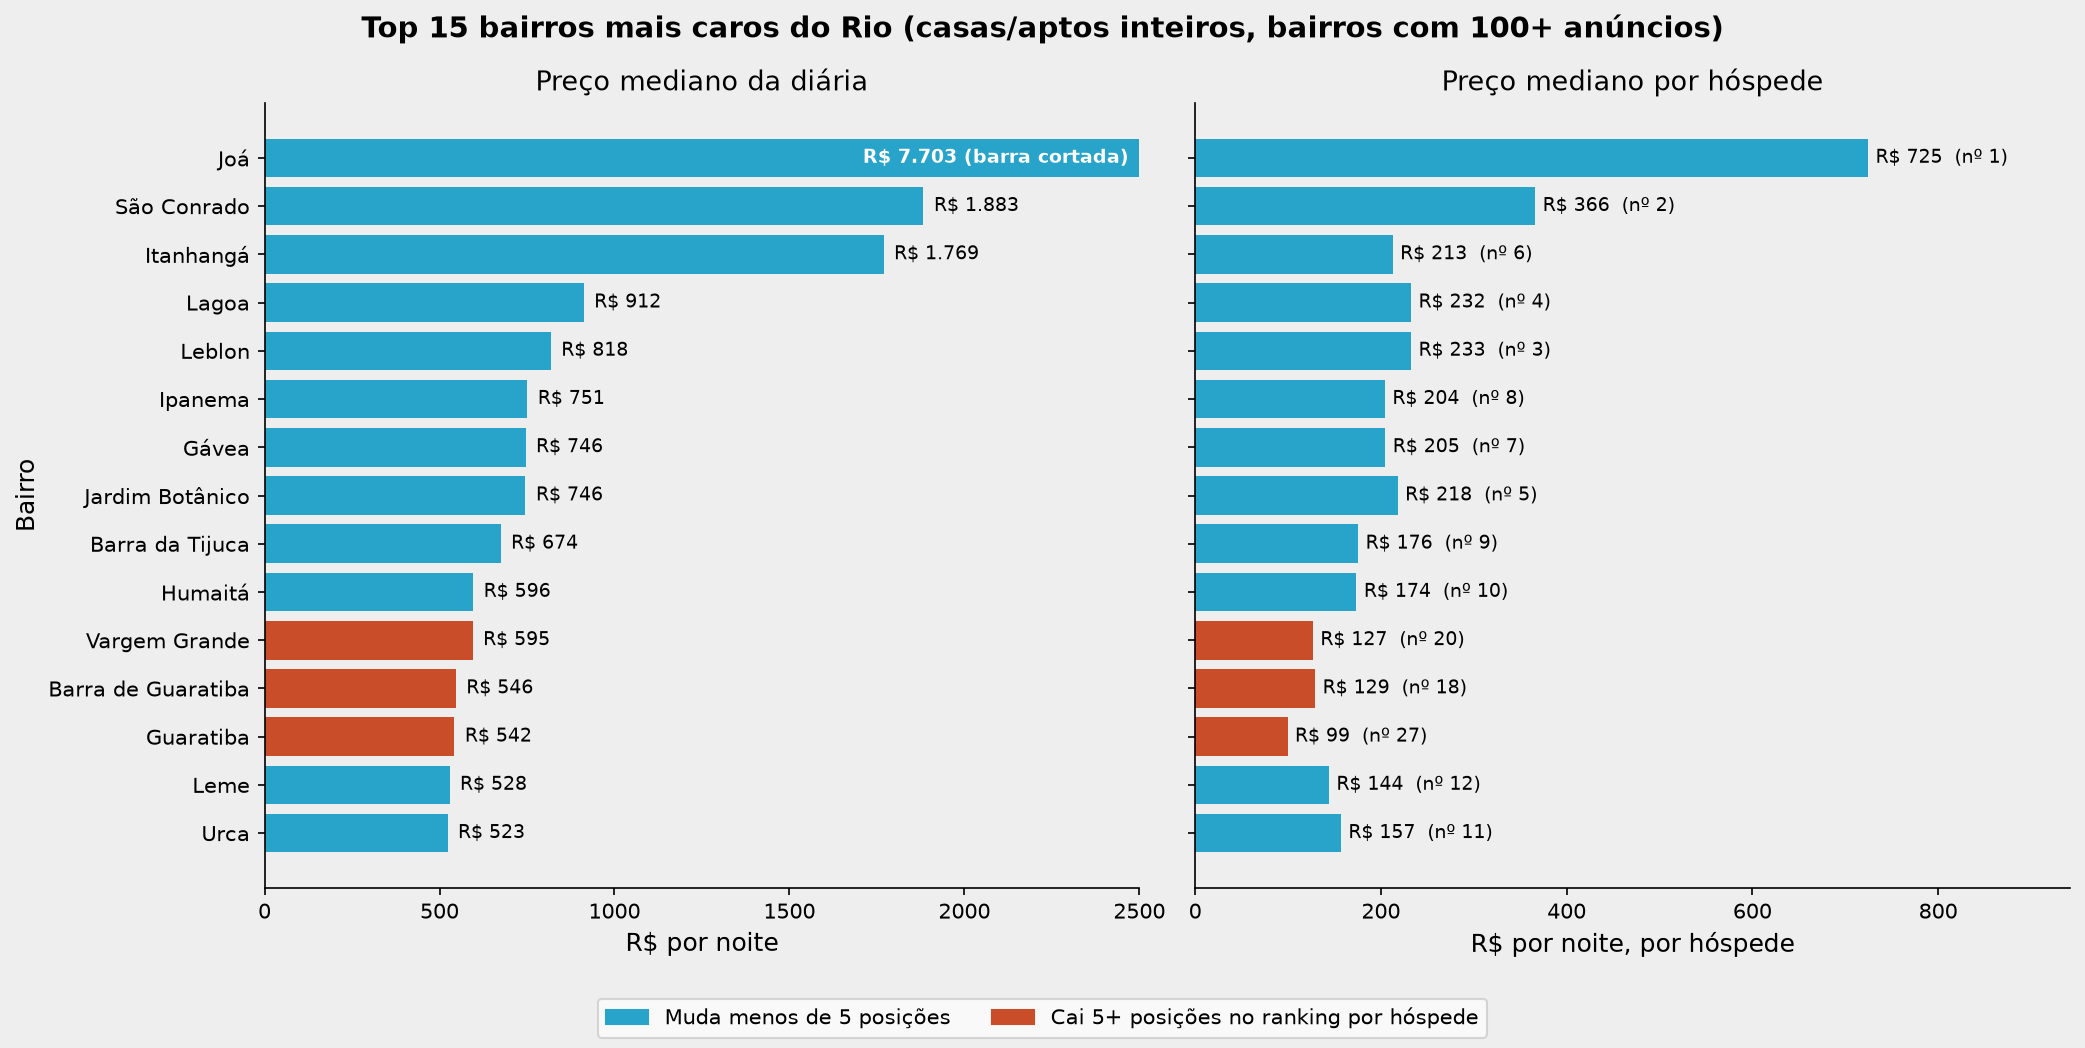

In [28]:
from matplotlib.patches import Patch

top15 = tabela_q3.head(15).iloc[::-1]

cores = np.where(top15['mudanca_posicao'] <= -5, '#c94d28', '#28a3c9')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), dpi=150, sharey=True)
fig.patch.set_facecolor('#eeeeee')

limite = 2500
ax1.barh(top15.index, top15['preco_mediano'], color=cores)
ax1.set_xlim(0, limite)
for i, valor in enumerate(top15['preco_mediano']):
    rotulo = f'R$ {valor:,.0f}'.replace(',', '.')
    if valor > limite:
        ax1.text(limite - 30, i, f'{rotulo} (barra cortada)', va='center', ha='right', fontsize=9, color='white', fontweight='bold')
    else:
        ax1.text(valor + 30, i, rotulo, va='center', fontsize=9)
ax1.set_title('Preço mediano da diária', fontsize=13)
ax1.set_xlabel('R$ por noite', fontsize=12)
ax1.set_ylabel('Bairro', fontsize=12)

ax2.barh(top15.index, top15['preco_hospede_mediano'], color=cores)
for i, (valor, posicao) in enumerate(zip(top15['preco_hospede_mediano'], top15['posicao_por_hospede'])):
    ax2.text(valor + 8, i, f'R$ {valor:,.0f}  (nº {posicao})'.replace(',', '.'), va='center', fontsize=9)
ax2.set_xlim(0, top15['preco_hospede_mediano'].max() * 1.3)
ax2.set_title('Preço mediano por hóspede', fontsize=13)
ax2.set_xlabel('R$ por noite, por hóspede', fontsize=12)

for ax in (ax1, ax2):
    ax.set_facecolor('#eeeeee')
    sns.despine(ax=ax, top=True, right=True)

fig.legend(
    handles=[Patch(color='#28a3c9', label='Muda menos de 5 posições'),
             Patch(color='#c94d28', label='Cai 5+ posições no ranking por hóspede')],
    loc='lower center', ncol=2, frameon=True, facecolor='#fdfdfd', fontsize=10
)
fig.suptitle('Top 15 bairros mais caros do Rio (casas/aptos inteiros, bairros com 100+ anúncios)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

Entre os 32 bairros com pelo menos 100 casas/aptos inteiros, o Joá está isolado no topo, com diária mediana de R$ 7.703. São basicamente mansões, com capacidade mediana de 10 hóspedes. Em seguida vêm São Conrado (R$ 1.883) e Itanhangá (R$ 1.769), e depois o bloco da Zona Sul (Lagoa, Leblon, Ipanema, Gávea e Jardim Botânico), entre R$ 745 e R$ 912. Os mais baratos são o Centro (R$ 285) e Campo Grande (R$ 228).

O ranking se mantém? Em grande parte, sim: a correlação de Spearman entre os dois rankings é de 0,85, o que indica forte concordância. Joá e São Conrado continuam em 1º e 2º, e Lagoa, Leblon, Jardim Botânico, Gávea e Ipanema ficam entre os 8 primeiros nos dois rankings. Ou seja, o preço mais alto desses bairros vem da localização, e não do tamanho dos imóveis.

As exceções estão na Zona Oeste, onde os imóveis são maiores: Guaratiba cai 14 posições (13º -> 27º), Vargem Grande e Vargem Pequena caem 9, Recreio dos Bandeirantes cai 8 e Barra de Guaratiba cai 6. Nesses bairros, a diária alta reflete casas que comportam mais pessoas, e não um valor maior por hóspede. No sentido oposto, Botafogo (23º -> 14º), Flamengo (24º -> 16º) e Catete (29º -> 21º) sobem: têm diárias moderadas, mas imóveis menores, então o preço por hóspede é relativamente alto.

**Limitações:** `accommodates` é a capacidade máxima do anúncio, e não o número real de hóspedes da reserva, então o preço por hóspede é um valor mínimo. Além disso, o preço de cada anúncio foi cotado para datas próximas da coleta (fim de junho de 2026, baixa temporada), o que pode não refletir períodos como Réveillon e Carnaval.

### Complemento da Pergunta 3: onde ficam esses bairros?

Para ver a localização dos bairros da tabela anterior, construímos um mapa apenas com matplotlib, usando a latitude e a longitude dos anúncios:
- **pontos cinza:** todos os anúncios da base. Eles desenham o formato da cidade e o contorno do litoral;
- **bolhas:** os 32 bairros da Pergunta 3, posicionadas na mediana da latitude e da longitude dos seus anúncios. O **tamanho** representa o nº de casas/aptos inteiros e a **cor**, o preço mediano por hóspede (a escala vai até R$ 250; Joá e São Conrado passam desse valor e aparecem com a cor mais escura);
- **triângulos azuis:** principais praias de mar;
- **X roxo:** algumas das principais favelas da cidade.

A base não informa onde ficam praias e favelas, então essas coordenadas foram **adicionadas manualmente** (valores aproximados, conferidos com a localização dos anúncios). Como a Zona Sul e o Centro concentram muitos bairros próximos, o primeiro mapa mostra a cidade inteira e o segundo faz um zoom nessa região.

In [29]:
#Centro aproximado de cada bairro: mediana da latitude e da longitude dos seus anúncios
centros = df_q3.groupby('neighbourhood_cleansed')[['latitude', 'longitude']].median()

#Junta com a tabela da Pergunta 3 (mantém só os bairros com 100+ anúncios)
mapa_bairros = tabela_q3[['anuncios', 'preco_hospede_mediano']].join(centros)
mapa_bairros = mapa_bairros.sort_values('preco_hospede_mediano', ascending=False).round(4)
display(mapa_bairros)

,anuncios,preco_hospede_mediano,latitude,longitude
Bairro,,,,
Joá,144,724.57,-23.0109,-43.2904
São Conrado,183,366.17,-22.9975,-43.2610
Leblon,1670,232.52,-22.9835,-43.2232
Lagoa,215,232.50,-22.9678,-43.2038
Jardim Botânico,137,218.07,-22.9627,-43.2184
Itanhangá,106,212.72,-22.9896,-43.3065
Gávea,164,204.77,-22.9772,-43.2296
Ipanema,3210,204.36,-22.9845,-43.1997
Barra da Tijuca,2957,175.50,-23.0090,-43.3424


In [30]:
#Pontos de referência adicionados manualmente (coordenadas aproximadas, conferidas com a localização dos anúncios)
#A última coluna indica de que lado do ponto o nome aparece no mapa, para os rótulos não se sobreporem
praias = pd.DataFrame([
    ('Praia de Copacabana', -22.9715, -43.1780, 'abaixo'),
    ('Praia de Ipanema', -22.9885, -43.2030, 'abaixo'),
    ('Praia do Leblon', -22.9890, -43.2230, 'abaixo'),
    ('Praia de São Conrado', -23.0010, -43.2660, 'abaixo'),
    ('Praia da Joatinga', -23.0155, -43.2895, 'abaixo'),
    ('Praia da Barra', -23.0125, -43.3500, 'abaixo'),
    ('Praia do Recreio', -23.0295, -43.4650, 'abaixo'),
    ('Prainha', -23.0410, -43.5065, 'direita'),
    ('Praia de Grumari', -23.0480, -43.5240, 'abaixo'),
], columns=['nome', 'latitude', 'longitude', 'rotulo'])

favelas = pd.DataFrame([
    ('Rocinha', -22.9885, -43.2490, 'direita'),
    ('Vidigal', -22.9955, -43.2385, 'abaixo'),
    ('Cantagalo /\nPavão-Pavãozinho', -22.9810, -43.1935, 'direita'),
    ('Babilônia /\nChapéu Mangueira', -22.9608, -43.1703, 'acima'),
    ('Santa Marta', -22.9500, -43.1940, 'esquerda'),
    ('Rio das Pedras', -22.9745, -43.3325, 'direita'),
    ('Cidade de Deus', -22.9480, -43.3615, 'direita'),
    ('Complexo do Alemão', -22.8600, -43.2680, 'esquerda'),
    ('Complexo da Maré', -22.8600, -43.2420, 'direita'),
], columns=['nome', 'latitude', 'longitude', 'rotulo'])

#Bairros cujo nome fica em outra posição (o padrão é acima da bolha)
rotulo_bairros = {'Vargem Grande': 'abaixo', 'Itanhangá': 'esquerda', 'Barra de Guaratiba': 'abaixo', 'Leme': 'esquerda',
                  'Glória': 'direita', 'Catete': 'esquerda', 'Santa Teresa': 'esquerda', 'Flamengo': 'direita',
                  'Santo Cristo': 'esquerda', 'São Cristóvão': 'abaixo', 'Lagoa': 'esquerda', 'Humaitá': 'esquerda',
                  'Botafogo': 'direita'}

In [31]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

#Escala de cor de um só tom: laranja claro (mais barato) -> marrom escuro (mais caro)
cmap_preco = LinearSegmentedColormap.from_list('preco', ['#e2875f', '#c94d28', '#8a2e14', '#4a170a'])

#Direção do texto em relação ao ponto e alinhamento para cada posição de rótulo
posicoes = {
    'acima': ((0, 1), 'center', 'bottom'),
    'abaixo': ((0, -1), 'center', 'top'),
    'direita': ((1, 0), 'left', 'center'),
    'esquerda': ((-1, 0), 'right', 'center'),
}

#Área do zoom: Zona Sul e Centro
zoom_lon = (-43.30, -43.155)
zoom_lat = (-23.022, -22.895)

def tamanho_bolha(anuncios):
    return 30 + anuncios / 12 #área da bolha proporcional ao nº de anúncios

def fora_do_zoom(lat, lon):
    return not (zoom_lon[0] <= lon <= zoom_lon[1] and zoom_lat[0] <= lat <= zoom_lat[1])

def escrever(ax, texto, lat, lon, posicao, distancia, **estilo):
    #distancia = quantos pontos o texto fica afastado do centro do marcador
    (dx, dy), alinhamento_h, alinhamento_v = posicoes[posicao]
    ax.annotate(texto, (lon, lat), xytext=(dx * distancia, dy * distancia), textcoords='offset points',
                ha=alinhamento_h, va=alinhamento_v, fontsize=8, zorder=5, **estilo)

def desenhar_mapa(ax, so_rotulos_fora_do_zoom):
    #1) Todos os anúncios em cinza: os pontos desenham o formato da cidade e o contorno do litoral
    ax.scatter(df['longitude'], df['latitude'], s=1, color='#c4c4c4', linewidths=0, zorder=1)

    #2) Praias (triângulo azul) e favelas (X roxo), desenhadas por baixo das bolhas para não escondê-las
    ax.scatter(praias['longitude'], praias['latitude'], marker='^', s=110, color='#1a86ab', edgecolor='white', linewidth=1, zorder=2)
    ax.scatter(favelas['longitude'], favelas['latitude'], marker='X', s=150, color='#7a3e9d', edgecolor='white', linewidth=1, zorder=2)

    #3) Bairros: bolha no centro do bairro | tamanho = nº de anúncios | cor = preço mediano por hóspede
    bolhas = ax.scatter(
        mapa_bairros['longitude'], mapa_bairros['latitude'],
        s=tamanho_bolha(mapa_bairros['anuncios']),
        c=mapa_bairros['preco_hospede_mediano'], cmap=cmap_preco, vmin=75, vmax=250,
        edgecolor='white', linewidth=1, alpha=0.9, zorder=3
    )

    #4) Nomes (no mapa da cidade, só o que fica fora da área do zoom, para não amontoar)
    for bairro, linha in mapa_bairros.iterrows():
        if bairro in favelas['nome'].values: #Vidigal é bairro e favela: o nome aparece só uma vez
            continue
        if so_rotulos_fora_do_zoom and not fora_do_zoom(linha['latitude'], linha['longitude']):
            continue
        raio = np.sqrt(tamanho_bolha(linha['anuncios'])) / 2
        escrever(ax, bairro, linha['latitude'], linha['longitude'], rotulo_bairros.get(bairro, 'acima'),
                 distancia=raio + 4, fontweight='bold', color='#222222')
    for tabela in [praias, favelas]:
        for _, linha in tabela.iterrows():
            if so_rotulos_fora_do_zoom and not fora_do_zoom(linha['latitude'], linha['longitude']):
                continue
            escrever(ax, linha['nome'], linha['latitude'], linha['longitude'], linha['rotulo'],
                     distancia=9, fontstyle='italic', color='#444444')

    ax.set_aspect(1 / np.cos(np.radians(22.95))) #corrige a distorção entre graus de latitude e longitude
    ax.set_facecolor('#eeeeee')
    ax.set_xticks([])
    ax.set_yticks([])
    return bolhas

def finalizar_mapa(fig, ax, bolhas, titulo):
    barra = fig.colorbar(bolhas, ax=ax, shrink=0.7, extend='max', pad=0.01)
    barra.set_label('Preço mediano por hóspede (R$)', fontsize=11)
    legenda = [
        Line2D([], [], marker='o', linestyle='', color='#c94d28', markeredgecolor='white',
               markersize=np.sqrt(tamanho_bolha(n)), label=f'Bairro com {n:,} anúncios'.replace(',', '.'))
        for n in [100, 1000, 10000]
    ] + [
        Line2D([], [], marker='^', linestyle='', color='#1a86ab', markersize=10, label='Praia'),
        Line2D([], [], marker='X', linestyle='', color='#7a3e9d', markersize=10, label='Favela'),
    ]
    ax.legend(handles=legenda, loc='upper center', bbox_to_anchor=(0.5, -0.01), ncol=5, fontsize=9,
              frameon=False, columnspacing=1.5, handlelength=3, handletextpad=0.8)
    ax.set_title(titulo, fontsize=14, fontweight='bold')
    fig.patch.set_facecolor('#eeeeee')

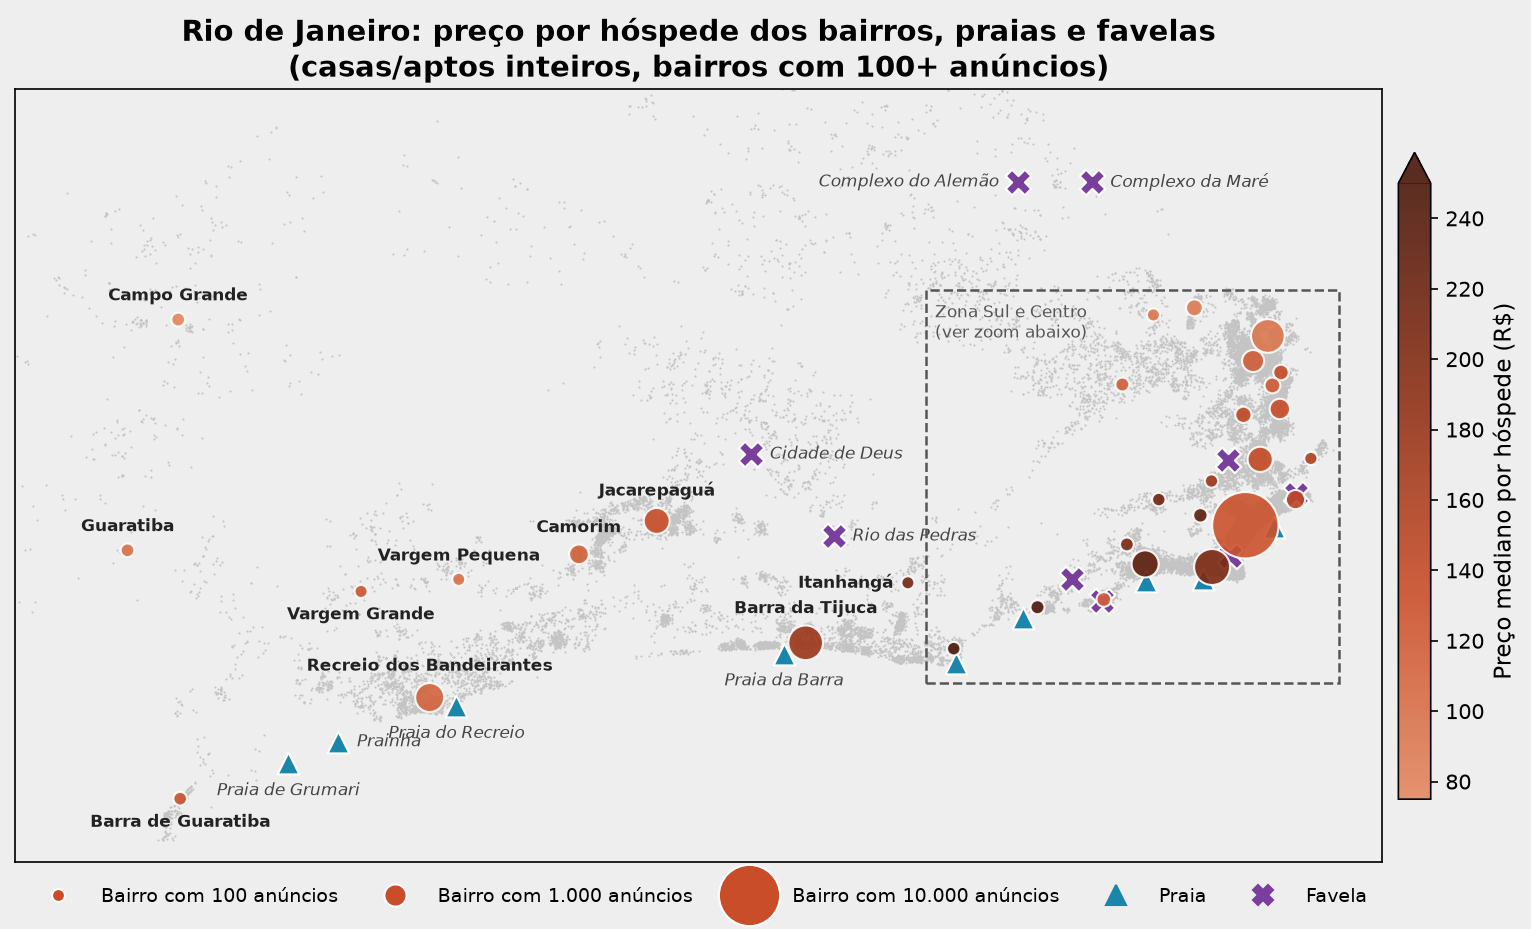

In [32]:
fig, ax = plt.subplots(figsize=(14, 8), dpi=150)
bolhas = desenhar_mapa(ax, so_rotulos_fora_do_zoom=True)
ax.set_xlim(-43.62, -43.14)
ax.set_ylim(-23.08, -22.83)

#Retângulo tracejado marcando a área que aparece no zoom
ax.add_patch(plt.Rectangle((zoom_lon[0], zoom_lat[0]), zoom_lon[1] - zoom_lon[0], zoom_lat[1] - zoom_lat[0],
                           fill=False, edgecolor='#555555', linestyle='--', linewidth=1.2, zorder=6))
ax.text(zoom_lon[0] + 0.003, zoom_lat[1] - 0.004, 'Zona Sul e Centro\n(ver zoom abaixo)',
        fontsize=8, color='#555555', va='top', zorder=6)

finalizar_mapa(fig, ax, bolhas, 'Rio de Janeiro: preço por hóspede dos bairros, praias e favelas\n(casas/aptos inteiros, bairros com 100+ anúncios)')
plt.show()

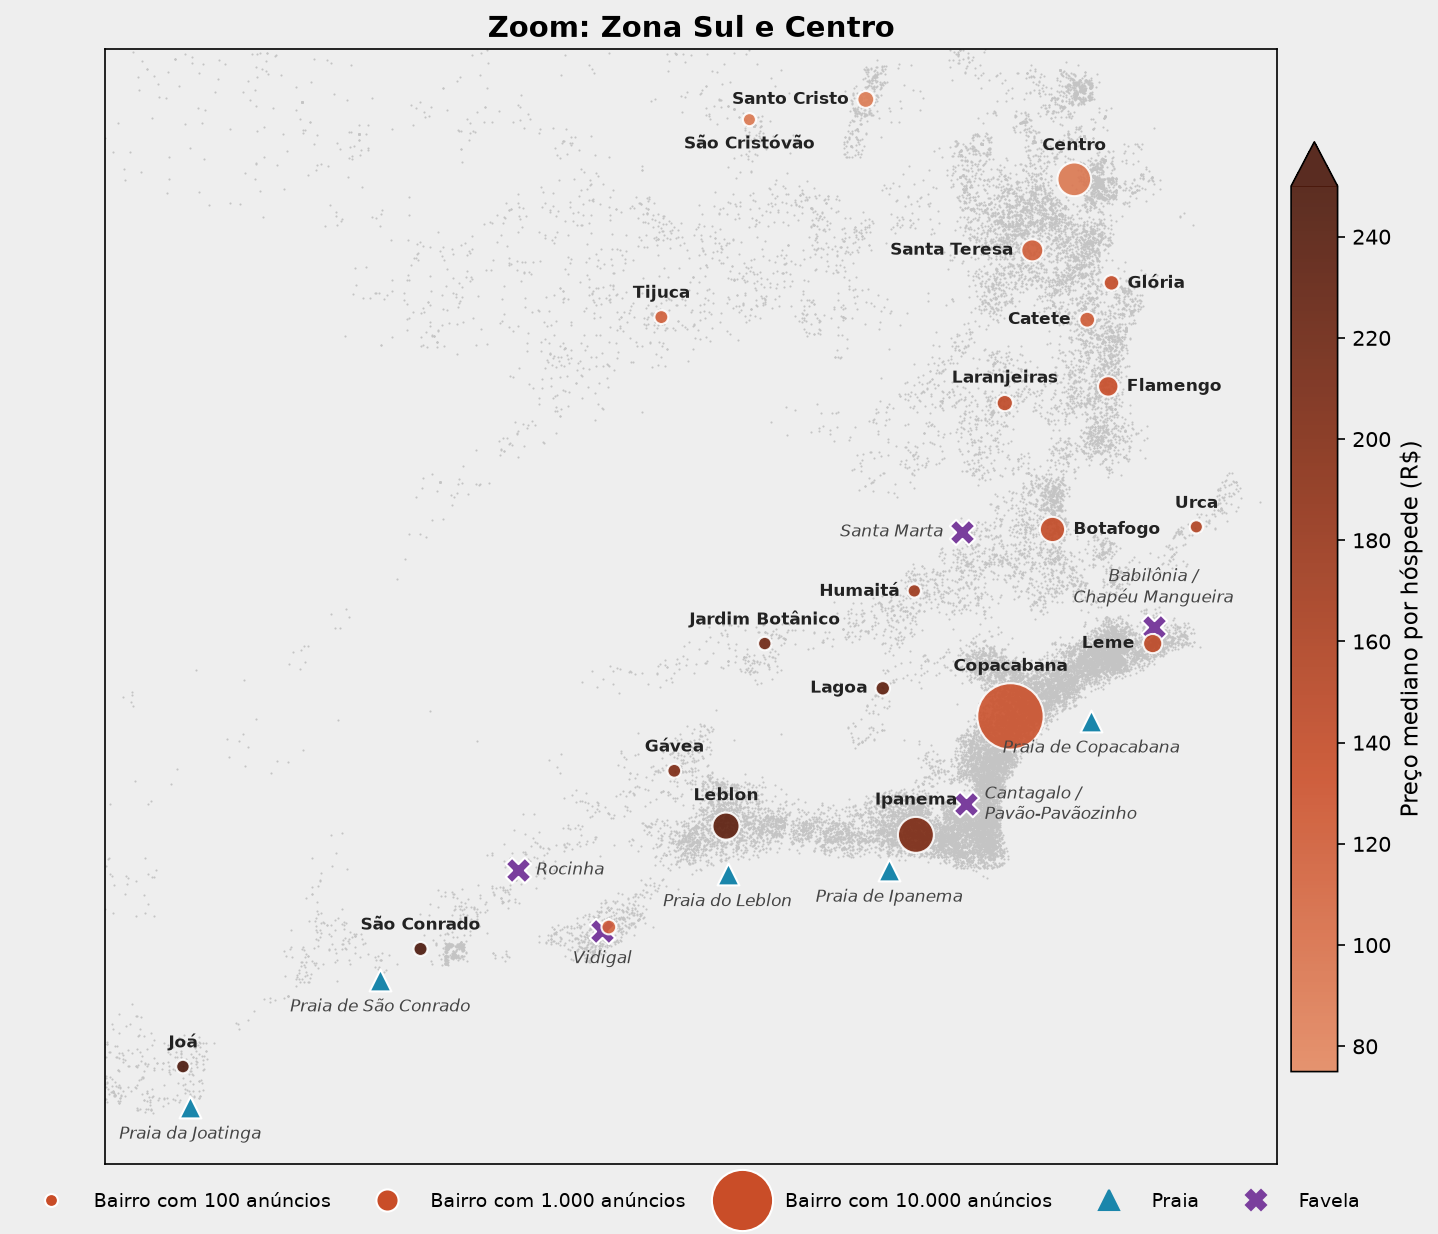

In [33]:
fig, ax = plt.subplots(figsize=(12, 11.5), dpi=150)
bolhas = desenhar_mapa(ax, so_rotulos_fora_do_zoom=False)
ax.set_xlim(zoom_lon)
ax.set_ylim(zoom_lat)
finalizar_mapa(fig, ax, bolhas, 'Zoom: Zona Sul e Centro')
plt.show()

In [34]:
#Quantos anúncios (de todos os tipos) existem nas favelas que são bairros oficiais na base?
bairros_favela = ['Vidigal', 'Rocinha', 'Cidade de Deus', 'Maré', 'Complexo do Alemão', 'Jacarezinho']
anuncios_favelas = df['neighbourhood_cleansed'].value_counts().reindex(bairros_favela, fill_value=0)
anuncios_favelas.index.name = 'Bairro (favela)'
anuncios_favelas.name = 'anuncios'
display(anuncios_favelas)

Bairro (favela)
Vidigal               508
Rocinha                93
Cidade de Deus         10
Maré                    2
Complexo do Alemão      1
Jacarezinho             0
Name: anuncios, dtype: int64

**Interpretação do mapa:**

- **Os anúncios se concentram no litoral.** Os pontos cinza formam uma faixa contínua da Zona Sul até a Barra e o Recreio, enquanto o interior e a Zona Norte têm poucos anúncios.
- **Os bairros mais caros por hóspede formam um bloco na Zona Sul, entre a Lagoa e o mar.** Leblon (R$ 232,52), Lagoa (R$ 232,50), Jardim Botânico (R$ 218), Gávea (R$ 205) e Ipanema (R$ 204), além de São Conrado (R$ 366) e Joá (R$ 725) logo a oeste. A cor clareia em direção ao Centro (R$ 91), à Zona Norte e ao extremo da Zona Oeste (Campo Grande, R$ 74,50).
- **Ter praia não basta.** Copacabana (R$ 128,50) e Recreio (R$ 110) têm praia, mas um preço por hóspede menor que o da Lagoa e do Jardim Botânico, que não têm praia de mar. O valor parece depender mais da região (Zona Sul nobre) do que apenas da proximidade com o mar.
- **As favelas da Zona Sul ficam coladas aos bairros mais caros.** O Vidigal (R$ 115 por hóspede) fica entre o Leblon e São Conrado, que cobram 2 a 3 vezes mais. A Rocinha fica entre a Gávea e São Conrado, o Cantagalo/Pavão-Pavãozinho entre Ipanema e Copacabana, e a Babilônia/Chapéu Mangueira no Leme.
- **A oferta de Airbnb em favelas se concentra nas que ficam perto das praias da Zona Sul.** A tabela acima mostra 508 anúncios no Vidigal e 93 na Rocinha, contra 10 na Cidade de Deus, 2 na Maré, 1 no Complexo do Alemão e nenhum no Jacarezinho.

**Limitações:** as coordenadas de praias e favelas foram adicionadas manualmente e são aproximadas. A bolha de cada bairro marca a mediana da localização dos seus anúncios, e não o centro geográfico oficial. Favelas que não são bairros oficiais (Cantagalo, Babilônia, Santa Marta, Rio das Pedras) não podem ser separadas na base, então seus anúncios entram em Copacabana, Leme, Botafogo e Jacarepaguá. Além disso, o próprio Airbnb desloca a localização dos anúncios em até cerca de 150 m para proteger a privacidade dos anfitriões.

## Conclusão

A análise dos 48.713 anúncios do Airbnb no Rio de Janeiro (coleta de junho de 2026) mostra que o preço e a demanda de uma acomodação dependem do que ela oferece, de quem anuncia e, principalmente, de onde ela fica.

**Pergunta 1 (amenidades e preço):** entre as cinco amenidades mais comuns, TV, cozinha e ar-condicionado são as mais associadas a preços maiores: a mediana de preço dos anúncios que as oferecem é 49%, 33% e 22% mais alta do que a dos que não oferecem. Wi-Fi (-1%) e água quente (-8%) não aparecem associados a preços maiores; o Wi-Fi, por exemplo, está em 92% dos anúncios e quase não diferencia um anúncio do outro. A associação se mantém quando comparamos acomodações com o mesmo número de quartos e banheiros, mas fica menos consistente nos imóveis maiores, onde há poucos dados.

**Pergunta 2 (Superhosts e demanda):** usando as avaliações por mês como proxy de demanda, os anúncios de Superhosts têm mediana de 1,59 avaliação por mês, contra 0,47 dos anfitriões comuns. O teste de Mann-Whitney rejeitou a hipótese de igualdade (p < 0,001), com tamanho de efeito entre 0,46 e 0,49 tanto no total quanto separando casas/apartamentos inteiros e quartos privativos. Como Superhosts também cobram um pouco menos e têm notas maiores, a diferença não pode ser atribuída apenas ao selo.

**Pergunta 3 (bairros e preço por hóspede):** Joá, São Conrado, Leblon, Lagoa, Jardim Botânico, Gávea e Ipanema estão entre os bairros mais caros e continuam no topo quando consideramos o preço por hóspede (correlação de Spearman de 0,85 entre os dois rankings). Já bairros da Zona Oeste como Guaratiba, Vargem Grande e Recreio caem bastante no ranking por hóspede: a diária alta desses bairros reflete casas grandes, e não uma localização mais valorizada. O mapa mostra ainda que as favelas da Zona Sul ficam ao lado dos bairros mais caros e que, entre as favelas que são bairros oficiais, o Vidigal concentra a maior parte dos anúncios.

**Limitações:** cada anúncio tem um único preço, cotado para datas próximas da coleta (fim de junho, baixa temporada), então a análise não captura a variação de preço em épocas como Réveillon e Carnaval. As avaliações por mês são apenas uma aproximação da demanda, já que nem todo hóspede deixa avaliação. Por fim, as três análises mostram associações, e não relações de causa e efeito: amenidades, selo de Superhost e localização variam junto com outras características dos anúncios que não foram controladas.